In [1]:
# importing packages
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from scipy.interpolate import griddata
import pandas as pd
import conductivity as cd
from matplotlib.gridspec import GridSpec

# Data for binary salt solutions

In [2]:
# loading NaCl and CaCl2 experiment data
data = pd.read_csv("./Data/NaCl_CaCl2_rearranged.csv")
NaCl_conc = data["NaCl conc"]
NaCl_conc12 = data["NaCl conc2"]
NaCl_conc13 = data["NaCl conc3"]
CaCl2_conc = data["CaCl2 conc"]
CaCl2_conc12 = data["CaCl2 conc2"]
CaCl2_conc13 = data["CaCl2 conc3"]
cond_exp_raw = data["Cal bulk cond"]
cond_exp12_raw = data["Cal bulk cond2"]
cond_exp13_raw = data["Cal bulk cond3"]

# number of data points
ndata = len(cond_exp_raw)

# convert the conductivity from micro.Siemen per cm to milli.Siemen per cm
cond_exp = [cond_exp_raw[i]/1000 for i in range(ndata)]
cond_exp12 = [cond_exp12_raw[i]/1000 for i in range(ndata)]
cond_exp13 = [cond_exp13_raw[i]/1000 for i in range(ndata)]

# measurement error in %
sigma_cond = 0.93

# measurement error in milli.Siemen per cm
error_na_ca_1_1 = [(sigma_cond/100) * cond_exp[i] for i in range(ndata)]
error_na_ca_1_2 = [(sigma_cond/100) * cond_exp12[i] for i in range(ndata)]
error_na_ca_2_1 = [(sigma_cond/100) * cond_exp13[i] for i in range(ndata)]

In [3]:
# loading CaCl2 and LaCl3 experiment data
data2 = pd.read_csv("./Data/CaCl2_LaCl3_rearranged.csv")
LaCl3_conc = data2["LaCl3 conc"]
LaCl3_conc12 = data2["LaCl3 conc2"]
LaCl3_conc13 = data2["LaCl3 conc3"]
CaCl2_conc2 = data2["CaCl2 conc"]
CaCl2_conc22 = data2["CaCl2 conc2"]
CaCl2_conc23 = data2["CaCl2 conc3"]
cond_exp2_raw = data2["Cal bulk cond"]
cond_exp22_raw = data2["Cal bulk cond2"]
cond_exp23_raw = data2["Cal bulk cond3"]

# number of data points
ndata2 = len(cond_exp2_raw)

# convert the conductivity from micro.Siemen per cm to milli.Siemen per cm
cond_exp2 = [cond_exp2_raw[i]/1000 for i in range(ndata2)]
cond_exp22 = [cond_exp22_raw[i]/1000 for i in range(ndata2)]
cond_exp23 = [cond_exp23_raw[i]/1000 for i in range(ndata2)]

# measurement error in milli.Siemen per cm
error_ca_la_1_1 = [(sigma_cond/100) * cond_exp2[i] for i in range(ndata2)]
error_ca_la_2_1 = [(sigma_cond/100) * cond_exp22[i] for i in range(ndata2)]
error_ca_la_1_2 = [(sigma_cond/100) * cond_exp23[i] for i in range(ndata2)]

In [4]:
# loading NaCl and LaCl3 experiment data
data4 = pd.read_csv("./Data/NaCl_LaCl3_rearranged.csv")
NaCl_conc2 = data4["NaCl conc"]
NaCl_conc22 = data4["NaCl conc2"]
NaCl_conc23 = data4["NaCl conc3"]
LaCl3_conc2 = data4["LaCl3 conc"]
LaCl3_conc22 = data4["LaCl3 conc2"]
LaCl3_conc23 = data4["LaCl3 conc3"]
cond_exp3_raw = data4["Cal bulk cond"]
cond_exp32_raw = data4["Cal bulk cond2"]
cond_exp33_raw = data4["Cal bulk cond3"]

# number of data points
ndata4 = len(cond_exp3_raw)

# convert the conductivity from micro.Siemen per cm to milli.Siemen per cm
cond_exp3 = [cond_exp3_raw[i]/1000 for i in range(ndata4)]
cond_exp32 = [cond_exp32_raw[i]/1000 for i in range(ndata4)]
cond_exp33 = [cond_exp33_raw[i]/1000 for i in range(ndata4)]

# measurement error in milli.Siemen per cm
error_na_la_1_1 = [(sigma_cond/100) * cond_exp3[i] for i in range(ndata4)]
error_na_la_3_1 = [(sigma_cond/100) * cond_exp32[i] for i in range(ndata4)]
error_na_la_1_2 = [(sigma_cond/100) * cond_exp33[i] for i in range(ndata4)]

# Mean spherical approximation (MSA) model conductivity predictions

## Constants

In [5]:
# temperature in K
T = 298.15

# diffusion coefficients at infinite dilution in m^2/s
Diff_Na = 1.334 * 10**(-9)
Diff_Cl = 2.032 * 10**(-9)
Diff_Ca = 0.792 * 10**(-9)
Diff_La = 0.619 * 10**(-9)

# valencies
z_Na = 1
z_Cl = -1
z_Ca = 2
z_La = 3

# hard sphere diameters in m
sigma_Cl = 2 * 181 * 10**(-12)
sigma_Ca = 2 * 100 * 10**(-12)
sigma_La = 2 * 118 * 10**(-12)
sigma_Na = 2 * 102 * 10**(-12)

# solvent viscosity in Pa.s
eta_msa = 0.89 * 10**(-3)

# relative permittivity
epsilon = 78.43

# limiting molar conductivity of ions in m^2.S/mol
lambda_0_Na_mol = 50.08 * 10**(-4)
lambda_0_Cl_mol = 76.31 * 10**(-4)
lambda_0_Ca_mol = 59.47 * 10**(-4)
lambda_0_La_mol = 69.7 * 10**(-4)

## Ionic strength function for plotting

In [39]:
def ionic_strength(salt_1_conc, salt_2_conc, valency):
    """ 
    Calculates the ionic strength of the salt solution

    Arguments:
        salt_1_conc: pandas.Series or list or numpy.ndarray
            Concentration of the highest-valence salt in mM
        salt_2_conc: pandas.Series or list or numpy.ndarray
            Concentration of the lowest-valence salt in mM
        valency: list
            Valency of ions in decreasing order

    Returns:
        ionic_strength: list
            Ionic strength of the salt solution
    """
    # get the number of datapoints
    ndata = len(salt_1_conc)
    
    # calculate the species concentration
    cation_1_conc = salt_1_conc
    cation_2_conc = salt_2_conc
    anion_conc = [valency[0] * salt_1_conc[i] + valency[1] * salt_2_conc[i] for i in range(ndata)]
    n_species = len(valency)
    
    # calculate the ionic stength of the solution
    ionic_strength = []
    for i in range(ndata):
        ion_conc = [cation_1_conc[i], cation_2_conc[i], anion_conc[i]]
        ionic_strength.append(0.5 * sum(ion_conc[j] * valency[j] ** 2 for j in range(n_species)))

    return ionic_strength

## NaCl and CaCl2

In [7]:
# constants
diffusion_coeff = [Diff_Ca, Diff_Na, Diff_Cl] # diffusion coefficients of Ca, Na, and Cl, respectively
valency = [z_Ca, z_Na, z_Cl] # valencies of Ca, Na, and Cl, respectively
diameter = [sigma_Ca, sigma_Na, sigma_Cl] # effective ionic diameters of Ca, Na, and Cl, respectively
lambda_0_Ca_Na_Cl = [lambda_0_Ca_mol, lambda_0_Na_mol, 
                     lambda_0_Cl_mol] # limiting molar conductivity of Ca, Na, and Cl, respectively

# predicted conductivity in milli.S/cm
all_cond_calc_con =cd.msa(valency, diameter, diffusion_coeff, T, eta_msa, epsilon, 
                          lambda_0_Ca_Na_Cl, CaCl2_conc, NaCl_conc)
all_cond_calc_con12 = cd.msa(valency, diameter, diffusion_coeff, T, eta_msa, epsilon, 
                             lambda_0_Ca_Na_Cl, CaCl2_conc12, NaCl_conc12)
all_cond_calc_con13 = cd.msa(valency, diameter, diffusion_coeff, T, eta_msa, epsilon, 
                             lambda_0_Ca_Na_Cl, CaCl2_conc13, NaCl_conc13)

Relaxation correction: [-0.11131282 -0.03908867 -0.08723811]
Hydrodynamic correction: [-0.34150633 -0.20230851 -0.12231221]
Relative ionic strength: [0.5   0.125 0.375]
Transport number: [0.29892433 0.12587281 0.57520287]
Ionic mobility: [1.92351992e+11 3.23986816e+11 4.93509152e+11]
Average mobility: 321740280365.1725
Alpha: [np.float64(0.0), np.float64(275118320719.5198), np.float64(381397438525.3039)]
zeta matrix: [[ 1.52379051 -0.94333929 -0.36537891]
 [ 0.90467922  2.09978239 -1.64833163]
 [ 0.59391835  0.55785826  1.03661575]]
Relaxation correction: [-0.10289564 -0.03539905 -0.08939632]
Hydrodynamic correction: [-0.32515356 -0.19264358 -0.11691451]
Relative ionic strength: [0.57142857 0.07142857 0.35714286]
Transport number: [0.35535614 0.07481772 0.56982614]
Ionic mobility: [1.92351992e+11 3.23986816e+11 4.93509152e+11]
Average mobility: 309310608411.8851
Alpha: [np.float64(0.0), np.float64(291839212056.0358), np.float64(374919546231.9188)]
zeta matrix: [[ 1.46130484 -0.71446761

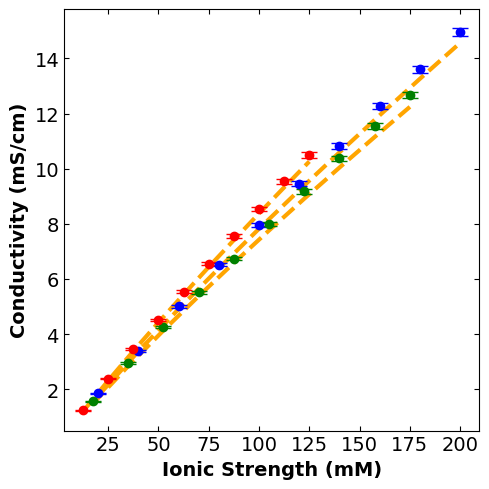

In [8]:
# compute the ionic strengths 
ionic_strength_na_ca_1_1 = ionic_strength(CaCl2_conc, NaCl_conc, valency)
ionic_strength_na_ca_1_2 = ionic_strength(CaCl2_conc12, NaCl_conc12, valency)
ionic_strength_na_ca_2_1 = ionic_strength(CaCl2_conc13, NaCl_conc13, valency)
# print(ionic_strength_na_ca_1_1)
# print(ionic_strength_na_ca_1_2)
# print(ionic_strength_na_ca_2_1)

# plot comparison of the MSA model predictions with the data
fig = plt.figure(figsize=(5, 5))
plt.plot(ionic_strength_na_ca_1_1, all_cond_calc_con, "--", color="orange", 
         linewidth=3, label="MSA")
plt.plot(ionic_strength_na_ca_1_2, all_cond_calc_con12, "--", color="orange", 
         linewidth=3)
plt.plot(ionic_strength_na_ca_2_1, all_cond_calc_con13, "--", color="orange", 
         linewidth=3)
plt.errorbar(
    ionic_strength_na_ca_1_1, cond_exp, yerr=error_na_ca_1_1, fmt='o', ecolor='blue', capsize=6, 
    markersize=6, markerfacecolor='blue', markeredgecolor='blue', label='1:1 Cation Data')
plt.errorbar(
    ionic_strength_na_ca_1_2, cond_exp12, yerr=error_na_ca_1_2, fmt='o', ecolor='green', capsize=6, 
    markersize=6, markerfacecolor='green', markeredgecolor='green', label='1:2 Cation Data')
plt.errorbar(
    ionic_strength_na_ca_2_1, cond_exp13, yerr=error_na_ca_2_1, fmt='o', ecolor='red', capsize=6, 
    markersize=6, markerfacecolor='red', markeredgecolor='red', label='2:1 Cation Data')
plt.xlabel("Ionic Strength (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Conductivity (mS/cm)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
# plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Binary_salts\msa_na_ca.png")
plt.show()

In [9]:
# prediction residuals for NaCl and CaCl2
e = [all_cond_calc_con[i] - cond_exp[i] for i in range(ndata)]
e12 = [all_cond_calc_con12[i] - cond_exp12[i] for i in range(ndata)]
e13 = [all_cond_calc_con13[i] - cond_exp13[i] for i in range(ndata)]

# percent prediction residuals
residuals_percent = [100*e[i]/cond_exp[i] for i in range(ndata)]
residuals_percent12 = [100*e12[i]/cond_exp12[i] for i in range(ndata)]
residuals_percent13 = [100*e13[i]/cond_exp13[i] for i in range(ndata)]

# calculate the mean absolute percent error
residuals_percent_abs = [np.abs(residuals_percent[i]) for i in range(ndata)]
residuals_percent12_abs = [np.abs(residuals_percent12[i]) for i in range(ndata)]
residuals_percent13_abs = [np.abs(residuals_percent13[i]) for i in range(ndata)]
print("The mean absolute percent error of 1:1 is:",np.mean(residuals_percent_abs))
print("The mean absolute percent error of 1:2 is:",np.mean(residuals_percent12_abs))
print("The mean absolute percent error of 2:1 is:",np.mean(residuals_percent13_abs))

# calculate the mean absolute error
residuals_abs = [np.abs(e[i]) for i in range(ndata)]
residuals_12_abs = [np.abs(e12[i]) for i in range(ndata)]
residuals_13_abs = [np.abs(e13[i]) for i in range(ndata)]
print("\nThe mean absolute error of 1:1 is:",np.mean(residuals_abs))
print("The mean absolute error of 1:2 is:",np.mean(residuals_12_abs))
print("The mean absolute error of 2:1 is:",np.mean(residuals_13_abs))

# calculate the mean squared error
sq_residuals = [e[i]**2 for i in range(ndata)]
sq_residuals_12 = [e12[i]**2 for i in range(ndata)]
sq_residuals_13 = [e13[i]**2 for i in range(ndata)]
print("\nThe mean squared error of 1:1 is:",np.mean(sq_residuals))
print("The mean squared error of 1:2 is:",np.mean(sq_residuals_12))
print("The mean squared error of 2:1 is:",np.mean(sq_residuals_13))

The mean absolute percent error of 1:1 is: 2.371217789787961
The mean absolute percent error of 1:2 is: 3.173985103124795
The mean absolute percent error of 2:1 is: 2.2722679374728387

The mean absolute error of 1:1 is: 0.20128123266173986
The mean absolute error of 1:2 is: 0.22541421023985966
The mean absolute error of 2:1 is: 0.12637028840083225

The mean squared error of 1:1 is: 0.054457999190780634
The mean squared error of 1:2 is: 0.06547757363365546
The mean squared error of 2:1 is: 0.019467040425105633


## CaCl2 and LaCl3

In [10]:
# constants
diffusion_coeff_2 = [Diff_La, Diff_Ca, Diff_Cl] # diffusion coefficients of La, Ca, and Cl, respectively
valency_2 = [z_La, z_Ca, z_Cl] # valencies of La, Ca, and Cl, respectively
diameter_2 = [sigma_La, sigma_Ca, sigma_Cl] # effective ionic diameters of La, Ca, and Cl, respectively
lambda_0_La_Ca_Cl = [lambda_0_La_mol, lambda_0_Ca_mol, lambda_0_Cl_mol]

# predicted conductivity in milli.S/cm
all_cond_calc_con2 = cd.msa(valency_2, diameter_2, diffusion_coeff_2, T, eta_msa, epsilon, 
                            lambda_0_La_Ca_Cl, LaCl3_conc, CaCl2_conc2)
all_cond_calc_con22 = cd.msa(valency_2, diameter_2, diffusion_coeff_2, T, eta_msa, epsilon, 
                             lambda_0_La_Ca_Cl, LaCl3_conc12, CaCl2_conc22)
all_cond_calc_con23 = cd.msa(valency_2, diameter_2, diffusion_coeff_2, T, eta_msa, epsilon, 
                             lambda_0_La_Ca_Cl, LaCl3_conc13, CaCl2_conc23)

Relaxation correction: [-0.15070863 -0.06378179 -0.11593789]
Hydrodynamic correction: [-0.41124116 -0.32758533 -0.11769067]
Relative ionic strength: [0.5        0.22222222 0.27777778]
Transport number: [0.2947775  0.16762792 0.53759458]
Ionic mobility: [1.50335711e+11 1.92351992e+11 4.93509152e+11]
Average mobility: 254998618549.4704
Alpha: [np.float64(0.0), np.float64(177514916972.4691), np.float64(357552337024.46356)]
zeta matrix: [[ 1.49560678 -0.98603166 -0.42812508]
 [ 1.1689149   2.0485397  -0.63459947]
 [ 0.45560069  0.13602522  1.27830472]]
Relaxation correction: [-0.17315487 -0.07731703 -0.11839039]
Hydrodynamic correction: [-0.45750594 -0.36525362 -0.13009999]
Relative ionic strength: [0.375      0.33333333 0.29166667]
Transport number: [0.21319506 0.24247063 0.54433432]
Ionic mobility: [1.50335711e+11 1.92351992e+11 4.93509152e+11]
Average mobility: 264433392030.6449
Alpha: [np.float64(0.0), np.float64(170446449841.20663), np.float64(357402378150.99304)]
zeta matrix: [[ 1.55

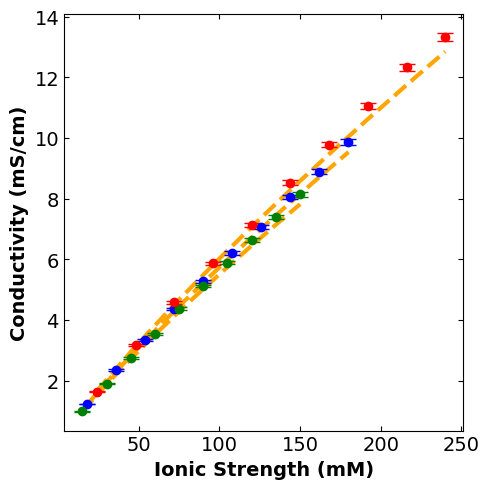

In [11]:
# calculate the ionic strengths
ionic_strength_ca_la_1_1 = ionic_strength(LaCl3_conc, CaCl2_conc2, valency_2)
ionic_strength_ca_la_2_1 = ionic_strength(LaCl3_conc12, CaCl2_conc22, valency_2)
ionic_strength_ca_la_1_2 = ionic_strength(LaCl3_conc13, CaCl2_conc23, valency_2)

# plot comparison of the MSA model predictions with the data
fig = plt.figure(figsize=(5, 5))
plt.plot(ionic_strength_ca_la_1_1, all_cond_calc_con2, "--", color="orange", linewidth=3, 
         label="MSA")
plt.plot(ionic_strength_ca_la_1_2, all_cond_calc_con23, "--", color="orange", linewidth=3)
plt.plot(ionic_strength_ca_la_2_1, all_cond_calc_con22, "--", color="orange", linewidth=3)
plt.errorbar(
    ionic_strength_ca_la_1_1, cond_exp2, yerr=error_ca_la_1_1, fmt='o', ecolor='blue', capsize=6, 
    markersize=6, markerfacecolor='blue', markeredgecolor='blue', label='1:1 Cation Data')
plt.errorbar(
    ionic_strength_ca_la_1_2, cond_exp23, yerr=error_ca_la_1_2, fmt='o', ecolor='green', capsize=6, 
    markersize=6, markerfacecolor='green', markeredgecolor='green', label='1:2 Cation Data')
plt.errorbar(
    ionic_strength_ca_la_2_1, cond_exp22, yerr=error_ca_la_2_1, fmt='o', ecolor='red', capsize=6, 
    markersize=6, markerfacecolor='red', markeredgecolor='red', label='2:1 Cation Data')
plt.xlabel("Ionic Strength (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Conductivity (mS/cm)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
# plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Binary_salts\msa_ca_la.png")
plt.show()

In [12]:
# prediction residuals for CaCl2 and LaCl3
e2 = [all_cond_calc_con2[i] - cond_exp2[i] for i in range(ndata2)]
e22 = [all_cond_calc_con22[i] - cond_exp22[i] for i in range(ndata2)]
e23 = [all_cond_calc_con23[i] - cond_exp23[i] for i in range(ndata2)]

# percent prediction residuals
residuals_percent2 = [100*e2[i]/cond_exp2[i] for i in range(ndata2)]
residuals_percent22 = [100*e22[i]/cond_exp22[i] for i in range(ndata2)]
residuals_percent23 = [100*e23[i]/cond_exp23[i] for i in range(ndata2)]

# calculate the mean absolute percent error
residuals_percent2_abs = [np.abs(residuals_percent2[i]) for i in range(ndata2)]
residuals_percent22_abs = [np.abs(residuals_percent22[i]) for i in range(ndata2)]
residuals_percent23_abs = [np.abs(residuals_percent23[i]) for i in range(ndata2)]
print("The mean absolute percent error of 1:1 is:",np.mean(residuals_percent2_abs))
print("The mean absolute percent error of 2:1 is:",np.mean(residuals_percent22_abs))
print("The mean absolute percent error of 1:2 is:",np.mean(residuals_percent23_abs))

# calculate the mean absolute error
residuals_2_abs = [np.abs(e2[i]) for i in range(ndata2)]
residuals_22_abs = [np.abs(e22[i]) for i in range(ndata2)]
residuals_23_abs = [np.abs(e23[i]) for i in range(ndata2)]
print("\nThe mean absolute error of 1:1 is:",np.mean(residuals_2_abs))
print("The mean absolute error of 2:1 is:",np.mean(residuals_22_abs))
print("The mean absolute error of 1:2 is:",np.mean(residuals_23_abs))

# calculate the mean squared error
sq_residuals_2 = [e2[i]**2 for i in range(ndata2)]
sq_residuals_22 = [e22[i]**2 for i in range(ndata2)]
sq_residuals_23 = [e23[i]**2 for i in range(ndata2)]
print("\nThe mean squared error of 1:1 is:",np.mean(sq_residuals_2))
print("The mean squared error of 2:1 is:",np.mean(sq_residuals_22))
print("The mean squared error of 1:2 is:",np.mean(sq_residuals_23))

The mean absolute percent error of 1:1 is: 1.597025758763872
The mean absolute percent error of 2:1 is: 2.4756931164211085
The mean absolute percent error of 1:2 is: 1.9780758852908757

The mean absolute error of 1:1 is: 0.10231572140567687
The mean absolute error of 2:1 is: 0.23259150204636025
The mean absolute error of 1:2 is: 0.11739622648141909

The mean squared error of 1:1 is: 0.018842900504981296
The mean squared error of 2:1 is: 0.09440211169554265
The mean squared error of 1:2 is: 0.024430964898585556


## NaCl and LaCl3

In [13]:
# constants
diffusion_coeff_3 = [Diff_La, Diff_Na, Diff_Cl] # diffusion coefficients of La, Na, and Cl, respectively
valency_3 = [z_La, z_Na, z_Cl] # valencies of La, Na, and Cl, respectively
diameter_3 = [sigma_La, sigma_Na, sigma_Cl] # effective ionic diameters of La, Na, and Cl, respectively
lambda_0_La_Na_Cl = [lambda_0_La_mol, lambda_0_Na_mol, lambda_0_Cl_mol]

# predicted conductivity in milli.S/cm
all_cond_calc_con3 = cd.msa(valency_3, diameter_3, diffusion_coeff_3, T, eta_msa, epsilon, 
                            lambda_0_La_Na_Cl, LaCl3_conc2, NaCl_conc2)
all_cond_calc_con32 = cd.msa(valency_3, diameter_3, diffusion_coeff_3, T, eta_msa, epsilon, 
                             lambda_0_La_Na_Cl, LaCl3_conc22, NaCl_conc22)
all_cond_calc_con33 = cd.msa(valency_3, diameter_3, diffusion_coeff_3, T, eta_msa, epsilon, 
                             lambda_0_La_Na_Cl, LaCl3_conc23, NaCl_conc23)

Relaxation correction: [-0.13744596 -0.01647846 -0.10720408]
Hydrodynamic correction: [-0.37274898 -0.17563275 -0.10724013]
Relative ionic strength: [0.64285714 0.07142857 0.28571429]
Transport number: [0.37058471 0.08873811 0.54067718]
Ionic mobility: [1.50335711e+11 3.23986816e+11 4.93509152e+11]
Average mobility: 260788916222.98755
Alpha: [np.float64(0.0), np.float64(280185123995.1825), np.float64(378474712351.5112)]
zeta matrix: [[ 1.50778913 -0.58944861 -0.27849707]
 [ 0.69964128  2.68345218 -1.89174574]
 [ 0.45931175  0.65539633  1.09955484]]
Relaxation correction: [-0.17116259 -0.02670757 -0.09893508]
Hydrodynamic correction: [-0.40925151 -0.19314246 -0.1171157 ]
Relative ionic strength: [0.5        0.16666667 0.33333333]
Transport number: [0.25596141 0.18387319 0.5601654 ]
Ionic mobility: [1.50335711e+11 3.23986816e+11 4.93509152e+11]
Average mobility: 293668709070.8091
Alpha: [np.float64(0.0), np.float64(242876329097.3079), np.float64(388092787538.2485)]
zeta matrix: [[ 1.6962

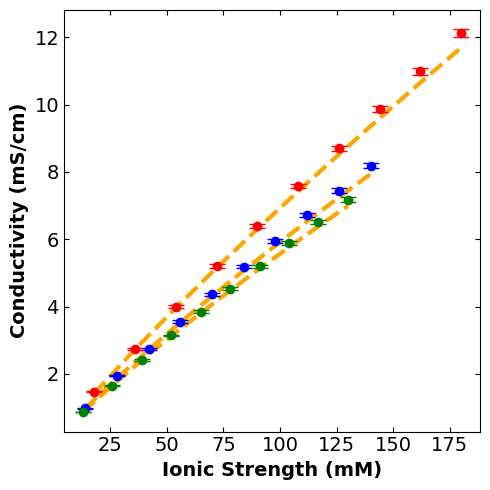

In [14]:
# calculate the ionic strengths
ionic_strength_na_la_1_1 = ionic_strength(LaCl3_conc2, NaCl_conc2, valency_3)
ionic_strength_na_la_3_1 = ionic_strength(LaCl3_conc22, NaCl_conc22, valency_3)
ionic_strength_na_la_1_2 = ionic_strength(LaCl3_conc23, NaCl_conc23, valency_3)

# plot comparison of the MSA model predictions with the data
fig = plt.figure(figsize=(5, 5))
plt.plot(ionic_strength_na_la_1_1, all_cond_calc_con3, "--", color="orange", linewidth=3, 
         label="MSA")
plt.plot(ionic_strength_na_la_1_2, all_cond_calc_con33, "--", color="orange", linewidth=3)
plt.plot(ionic_strength_na_la_3_1, all_cond_calc_con32, "--", color="orange", linewidth=3)
plt.errorbar(
    ionic_strength_na_la_1_1, cond_exp3, yerr=error_na_la_1_1, fmt='o', ecolor='blue', capsize=6, 
    markersize=6, markerfacecolor='blue', markeredgecolor='blue', label='1:1 Cation Data')
plt.errorbar(
    ionic_strength_na_la_1_2, cond_exp33, yerr=error_na_la_1_2, fmt='o', ecolor='green', capsize=6, 
    markersize=6, markerfacecolor='green', markeredgecolor='green', label='1:2 Cation Data')
plt.errorbar(
    ionic_strength_na_la_3_1, cond_exp32, yerr=error_na_la_3_1, fmt='o', ecolor='red', capsize=6, 
    markersize=6, markerfacecolor='red', markeredgecolor='red', label='3:1 Cation Data')
plt.xlabel("Ionic Strength (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Conductivity (mS/cm)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
# plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Binary_salts\msa_na_la.png")
plt.show()

In [15]:
# prediction residuals for NaCl and LaCl3
e3 = [all_cond_calc_con3[i] - cond_exp3[i] for i in range(ndata4)]
e32 = [all_cond_calc_con32[i] - cond_exp32[i] for i in range(ndata4)]
e33 = [all_cond_calc_con33[i] - cond_exp33[i] for i in range(ndata4)]

# percent prediction residuals
residuals_percent3 = [100*e3[i]/cond_exp3[i] for i in range(ndata4)]
residuals_percent32 = [100*e32[i]/cond_exp32[i] for i in range(ndata4)]
residuals_percent33 = [100*e33[i]/cond_exp33[i] for i in range(ndata4)]

# calculate the mean absolute percent error
residuals_percent3_abs = [np.abs(residuals_percent3[i]) for i in range(ndata4)]
residuals_percent32_abs = [np.abs(residuals_percent32[i]) for i in range(ndata4)]
residuals_percent33_abs = [np.abs(residuals_percent33[i]) for i in range(ndata4)]
print("The mean absolute percent error of 1:1 is:",np.mean(residuals_percent3_abs))
print("The mean absolute percent error of 3:1 is:",np.mean(residuals_percent32_abs))
print("The mean absolute percent error of 1:2 is:",np.mean(residuals_percent33_abs))

# calculate the mean absolute error
residuals_3_abs = [np.abs(e3[i]) for i in range(ndata4)]
residuals_32_abs = [np.abs(e32[i]) for i in range(ndata4)]
residuals_33_abs = [np.abs(e33[i]) for i in range(ndata4)]
print("\nThe mean absolute error of 1:1 is:",np.mean(residuals_3_abs))
print("The mean absolute error of 3:1 is:",np.mean(residuals_32_abs))
print("The mean absolute error of 1:2 is:",np.mean(residuals_33_abs))

# calculate the mean squared error
sq_residuals_3 = [e3[i]**2 for i in range(ndata4)]
sq_residuals_32 = [e32[i]**2 for i in range(ndata4)]
sq_residuals_33 = [e33[i]**2 for i in range(ndata4)]
print("\nThe mean squared error of 1:1 is:",np.mean(sq_residuals_3))
print("The mean squared error of 3:1 is:",np.mean(sq_residuals_32))
print("The mean squared error of 1:2 is:",np.mean(sq_residuals_33))

The mean absolute percent error of 1:1 is: 1.9341418940463833
The mean absolute percent error of 3:1 is: 2.024625966587803
The mean absolute percent error of 1:2 is: 1.3278691826891218

The mean absolute error of 1:1 is: 0.10394609747423975
The mean absolute error of 3:1 is: 0.16264755099402514
The mean absolute error of 1:2 is: 0.06629430993175758

The mean squared error of 1:1 is: 0.01743947902744056
The mean squared error of 3:1 is: 0.04520929863550223
The mean squared error of 1:2 is: 0.00795167460786448


# Shedlovsky model conductivity predictions

## NaCl and CaCl2

### Constants

In [16]:
# solvent viscosity in poise
eta_shed = 8.9*10**(-3)

# limiting equivalent conductivity of salts in cm^2.Siemen.equiv^(-1)
lambda_0_NaCl = 126.45 
lambda_0_CaCl2 = 135.85
lambda_0_LaCl3 = 145.9

# limiting equivalent conductivity of ions in cm^2.Siemen.equiv^(-1)
lambda_0_Na = 50.10
lambda_0_Ca = 59.5
lambda_0_La = 69.7
lambda_0_Cl = 76.35

# distance from an ion within which no other ion can penetrate in cm
a_NaCl = 4*10**(-8)
a_CaCl2 = 4.31*10**(-8)
a_LaCl3 = 4.9*10**(-8)

### NaCl

In [17]:
# constants
a_NaCl_CaCl2 = (a_NaCl + a_CaCl2)/2

# concentration in M
conc = [NaCl_conc[i]*10**(-3) for i in range(ndata)]
conc12 = [NaCl_conc12[i]*10**(-3) for i in range(ndata)]
conc13 = [NaCl_conc13[i]*10**(-3) for i in range(ndata)]

# conductivity in milli.S/cm
specific_cond_nacl = cd.shedlovsky(conc, T, epsilon, eta_shed, lambda_0_NaCl, a_NaCl_CaCl2, 
                                   z_Na, z_Cl, lambda_0_Na, lambda_0_Cl)
specific_cond_nacl_12 = cd.shedlovsky(conc12, T, epsilon, eta_shed, lambda_0_NaCl, a_NaCl_CaCl2, 
                                      z_Na, z_Cl, lambda_0_Na, lambda_0_Cl)
specific_cond_nacl_13 = cd.shedlovsky(conc13, T, epsilon, eta_shed, lambda_0_NaCl, a_NaCl_CaCl2, 
                                      z_Na, z_Cl, lambda_0_Na, lambda_0_Cl)

### CaCl2

In [18]:
# concentration in M
conc_cacl2 = [CaCl2_conc[i]*10**(-3) for i in range(ndata)]
conc_cacl2_12 = [CaCl2_conc12[i]*10**(-3) for i in range(ndata)]
conc_cacl2_13 = [CaCl2_conc13[i]*10**(-3) for i in range(ndata)]

# conductivity in milli.S/cm
specific_cond_cacl2 = cd.shedlovsky(conc_cacl2, T, epsilon, eta_shed, lambda_0_CaCl2, a_NaCl_CaCl2, 
                                    z_Ca, z_Cl, lambda_0_Ca, lambda_0_Cl)
specific_cond_cacl2_12 = cd.shedlovsky(conc_cacl2_12, T, epsilon, eta_shed, lambda_0_CaCl2, a_NaCl_CaCl2, 
                                       z_Ca, z_Cl, lambda_0_Ca, lambda_0_Cl)
specific_cond_cacl2_13 = cd.shedlovsky(conc_cacl2_13, T, epsilon, eta_shed, lambda_0_CaCl2, a_NaCl_CaCl2, 
                                       z_Ca, z_Cl, lambda_0_Ca, lambda_0_Cl)

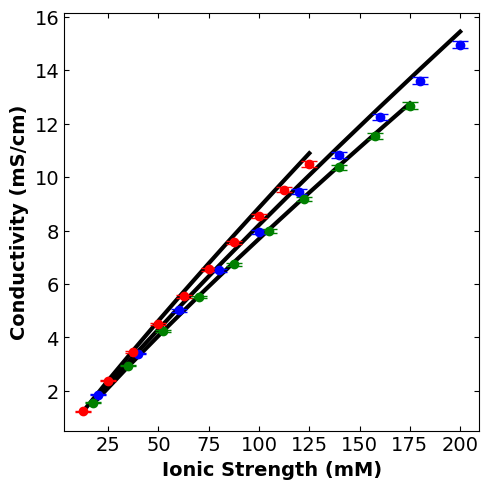

In [19]:
# bulk conductivity
specific_cond = [specific_cond_nacl[i] + specific_cond_cacl2[i] for i in range(ndata)]
specific_cond_12 = [specific_cond_nacl_12[i] + specific_cond_cacl2_12[i] for i in range(ndata)]
specific_cond_13 = [specific_cond_nacl_13[i] + specific_cond_cacl2_13[i] for i in range(ndata)]

# plot comparison of the Shedlovsky model predictions with the data
fig = plt.figure(figsize=(5, 5))
plt.plot(ionic_strength_na_ca_1_1, specific_cond, "-", color="black", linewidth=3, 
         label="Shedlovsky")
plt.plot(ionic_strength_na_ca_1_2, specific_cond_12, "-", linewidth=3, color="black")
plt.plot(ionic_strength_na_ca_2_1, specific_cond_13, "-", color="black", linewidth=3)
plt.errorbar(
    ionic_strength_na_ca_1_1, cond_exp, yerr=error_na_ca_1_1, fmt='o', ecolor='blue', capsize=6, 
    markersize=6, markerfacecolor='blue', markeredgecolor='blue', label='1:1 Cation Data')
plt.errorbar(
    ionic_strength_na_ca_1_2, cond_exp12, yerr=error_na_ca_1_2, fmt='o', ecolor='green', capsize=6, 
    markersize=6, markerfacecolor='green', markeredgecolor='green', label='1:2 Cation Data')
plt.errorbar(
    ionic_strength_na_ca_2_1, cond_exp13, yerr=error_na_ca_2_1, fmt='o', ecolor='red', capsize=6, 
    markersize=6, markerfacecolor='red', markeredgecolor='red', label='2:1 (a-d) or 3:1 (e-f) Cation Data')
plt.xlabel("Ionic Strength (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Conductivity (mS/cm)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
# plt.legend(prop={"weight":"bold"}, bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig(r".\Binary_salts\shed_na_ca.png")
plt.show()

In [20]:
# prediction residuals for NaCl and CaCl2
e_2 = [specific_cond[i] - cond_exp[i] for i in range(ndata)]
e12_2 = [specific_cond_12[i] - cond_exp12[i] for i in range(ndata)]
e13_2 = [specific_cond_13[i] - cond_exp13[i] for i in range(ndata)]

The mean absolute percent error of 1:1 is: 2.8057411654846716
The mean absolute percent error of 1:2 is: 0.9021161834899601
The mean absolute percent error of 2:1 is: 2.649670374283311

The mean absolute error of 1:1 is: 0.25423146934222995
The mean absolute error of 1:2 is: 0.05278500606737337
The mean absolute error of 2:1 is: 0.1911730030475171

The mean squared error of 1:1 is: 0.0855530336711915
The mean squared error of 1:2 is: 0.003333793147386461
The mean squared error of 2:1 is: 0.05459648133348342


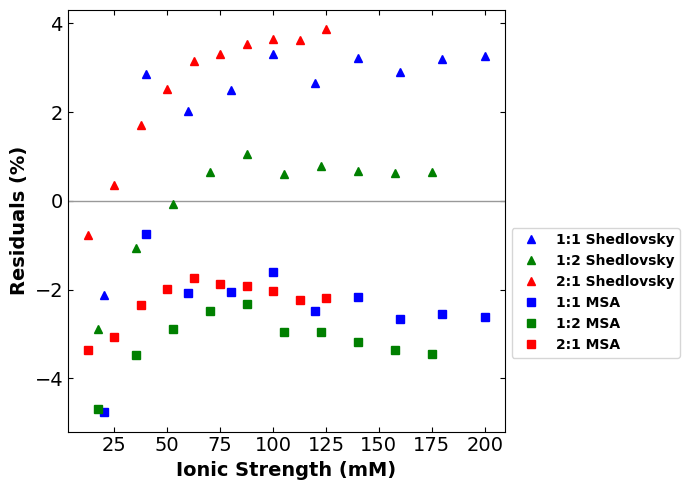

In [21]:
# percent prediction residuals
residuals_percent_2 = [100*e_2[i]/cond_exp[i] for i in range(ndata)]
residuals_percent12_2 = [100*e12_2[i]/cond_exp12[i] for i in range(ndata)]
residuals_percent13_2 = [100*e13_2[i]/cond_exp13[i] for i in range(ndata)]

# calculate the mean absolute percent error
residuals_percent_2_abs = [np.abs(residuals_percent_2[i]) for i in range(ndata)]
residuals_percent12_2_abs = [np.abs(residuals_percent12_2[i]) for i in range(ndata)]
residuals_percent13_2_abs = [np.abs(residuals_percent13_2[i]) for i in range(ndata)]
print("The mean absolute percent error of 1:1 is:",np.mean(residuals_percent_2_abs))
print("The mean absolute percent error of 1:2 is:",np.mean(residuals_percent12_2_abs))
print("The mean absolute percent error of 2:1 is:",np.mean(residuals_percent13_2_abs))

# calculate the mean absolute error
residuals_abs_shed = [np.abs(e_2[i]) for i in range(ndata)]
residuals_12_abs_shed = [np.abs(e12_2[i]) for i in range(ndata)]
residuals_13_abs_shed = [np.abs(e13_2[i]) for i in range(ndata)]
print("\nThe mean absolute error of 1:1 is:",np.mean(residuals_abs_shed))
print("The mean absolute error of 1:2 is:",np.mean(residuals_12_abs_shed))
print("The mean absolute error of 2:1 is:",np.mean(residuals_13_abs_shed))

# calculate the mean squared error
sq_residuals_shed = [e_2[i]**2 for i in range(ndata)]
sq_residuals_12_shed = [e12_2[i]**2 for i in range(ndata)]
sq_residuals_13_shed = [e13_2[i]**2 for i in range(ndata)]
print("\nThe mean squared error of 1:1 is:",np.mean(sq_residuals_shed))
print("The mean squared error of 1:2 is:",np.mean(sq_residuals_12_shed))
print("The mean squared error of 2:1 is:",np.mean(sq_residuals_13_shed))

# plot the prediction residuals of the Shedlovsky and MSA models
fig = plt.figure(figsize=(7, 5))
plt.axhline(0, color="0.6", lw=1)
plt.plot(ionic_strength_na_ca_1_1, residuals_percent_2, "^", color="blue", label="1:1 Shedlovsky")
plt.plot(ionic_strength_na_ca_1_2, residuals_percent12_2, "^", color="green", label="1:2 Shedlovsky")
plt.plot(ionic_strength_na_ca_2_1, residuals_percent13_2, "^", color="red", label="2:1 Shedlovsky")
plt.plot(ionic_strength_na_ca_1_1, residuals_percent, "s", color="blue", label="1:1 MSA")
plt.plot(ionic_strength_na_ca_1_2, residuals_percent12, "s", color="green", label="1:2 MSA")
plt.plot(ionic_strength_na_ca_2_1, residuals_percent13, "s", color="red", label="2:1 MSA")
plt.xlabel("Ionic Strength (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"}, bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig(r".\Binary_salts\msa_shed_na_ca_residuals_per.png")
plt.show()

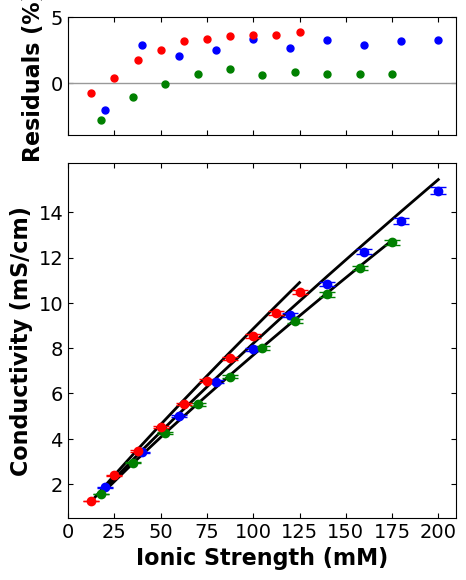

In [22]:
# generate paper figure for the Shedlovsky model
fig = plt.figure(figsize=(5, 6.5))
gs = GridSpec(2, 1, height_ratios=[1, 3], hspace=0.12)

ax_res = fig.add_subplot(gs[0])
ax_cond = fig.add_subplot(gs[1], sharex=ax_res)

# top plot
ax_res.axhline(0, color="0.6", lw=1)
ax_res.plot(ionic_strength_na_ca_1_1, residuals_percent_2, ".", color="blue", markersize=10)
ax_res.plot(ionic_strength_na_ca_1_2, residuals_percent12_2, ".", color="green", markersize=10)
ax_res.plot(ionic_strength_na_ca_2_1, residuals_percent13_2, ".", color="red", markersize=10)

ax_res.set_ylabel("Residuals (%)", fontsize=16, fontweight="bold")
ax_res.set_ylim(-4, 5)
ax_res.tick_params(direction="in", top=True, right=True, labelsize=14)
plt.setp(ax_res.get_xticklabels(), visible=False)

# bottom plot
ax_cond.plot(ionic_strength_na_ca_1_1, specific_cond, "-", color="black", linewidth=2,)
ax_cond.plot(ionic_strength_na_ca_1_2, specific_cond_12, "-", linewidth=2, color="black")
ax_cond.plot(ionic_strength_na_ca_2_1, specific_cond_13, "-", color="black", linewidth=2)
plt.errorbar(
    ionic_strength_na_ca_1_1, cond_exp, yerr=error_na_ca_1_1, fmt='o', ecolor='blue', capsize=6, 
    markersize=6, markerfacecolor='blue', markeredgecolor='blue', label='1:1 Cation Data')
plt.errorbar(
    ionic_strength_na_ca_1_2, cond_exp12, yerr=error_na_ca_1_2, fmt='o', ecolor='green', capsize=6, 
    markersize=6, markerfacecolor='green', markeredgecolor='green', label='1:2 Cation Data')
plt.errorbar(
    ionic_strength_na_ca_2_1, cond_exp13, yerr=error_na_ca_2_1, fmt='o', ecolor='red', capsize=6, 
    markersize=6, markerfacecolor='red', markeredgecolor='red', label='2:1 Cation Data')

ax_cond.set_xlabel("Ionic Strength (mM)", fontsize=16, fontweight="bold")
ax_cond.set_ylabel("Conductivity (mS/cm)", fontsize=16, fontweight="bold")

ax_cond.set_xticks([0, 25, 50, 75, 100, 125, 150, 175, 200])
ax_cond.set_yticks([2, 4, 6, 8, 10, 12, 14])
ax_cond.tick_params(direction="in", top=True, right=True, labelsize=14)

plt.savefig(r".\Binary_salts\shed_na_ca_combined.png")
plt.show()

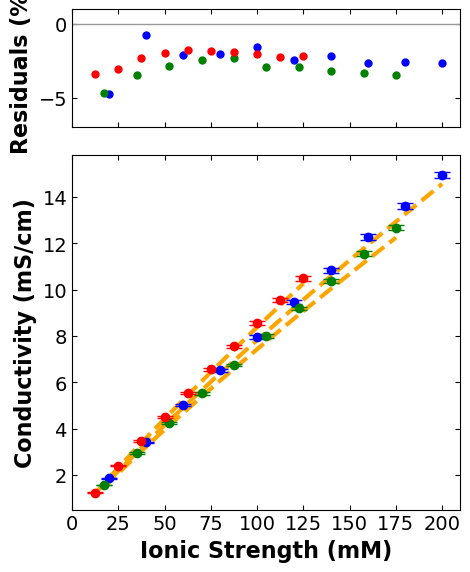

In [23]:
# generate paper figure for the MSA model
fig = plt.figure(figsize=(5, 6.5))
gs = GridSpec(2, 1, height_ratios=[1, 3], hspace=0.12)

ax_res = fig.add_subplot(gs[0])
ax_cond = fig.add_subplot(gs[1], sharex=ax_res)

# top plot
ax_res.axhline(0, color="0.6", lw=1)
ax_res.plot(ionic_strength_na_ca_1_1, residuals_percent, ".", color="blue", markersize=10)
ax_res.plot(ionic_strength_na_ca_1_2, residuals_percent12, ".", color="green", markersize=10)
ax_res.plot(ionic_strength_na_ca_2_1, residuals_percent13, ".", color="red", markersize=10)

ax_res.set_ylabel("Residuals (%)", fontsize=16, fontweight="bold")
ax_res.set_ylim(-7, 1)
ax_res.tick_params(direction="in", top=True, right=True, labelsize=14)
plt.setp(ax_res.get_xticklabels(), visible=False)

# bottom plot
ax_cond.plot(ionic_strength_na_ca_1_1, all_cond_calc_con, "--", color="orange", linewidth=3,)
ax_cond.plot(ionic_strength_na_ca_1_2, all_cond_calc_con12, "--", linewidth=3, color="orange")
ax_cond.plot(ionic_strength_na_ca_2_1, all_cond_calc_con13, "--", color="orange", linewidth=3)
plt.errorbar(
    ionic_strength_na_ca_1_1, cond_exp, yerr=error_na_ca_1_1, fmt='o', ecolor='blue', capsize=6, 
    markersize=6, markerfacecolor='blue', markeredgecolor='blue', label='1:1 Cation Data')
plt.errorbar(
    ionic_strength_na_ca_1_2, cond_exp12, yerr=error_na_ca_1_2, fmt='o', ecolor='green', capsize=6, 
    markersize=6, markerfacecolor='green', markeredgecolor='green', label='1:2 Cation Data')
plt.errorbar(
    ionic_strength_na_ca_2_1, cond_exp13, yerr=error_na_ca_2_1, fmt='o', ecolor='red', capsize=6, 
    markersize=6, markerfacecolor='red', markeredgecolor='red', label='2:1 Cation Data')

ax_cond.set_xlabel("Ionic Strength (mM)", fontsize=16, fontweight="bold")
ax_cond.set_ylabel("Conductivity (mS/cm)", fontsize=16, fontweight="bold")

ax_cond.set_xticks([0, 25, 50, 75, 100, 125, 150, 175, 200])
ax_cond.tick_params(direction="in", top=True, right=True, labelsize=14)

plt.savefig(r".\Binary_salts\msa_na_ca_combined.png")
plt.show()

## NaCl and LaCl3

### NaCl

In [24]:
# constants
a_NaCl_LaCl3 = (a_NaCl + a_LaCl3)/2

# concentration in M
conc_nacl_21 = [NaCl_conc2[i]*10**(-3) for i in range(ndata4)]
conc_nacl_22 = [NaCl_conc22[i]*10**(-3) for i in range(ndata4)]
conc_nacl_23 = [NaCl_conc23[i]*10**(-3) for i in range(ndata4)]

# conductivity in milli.S/cm
specific_cond_nacl_21 = cd.shedlovsky(conc_nacl_21, T, epsilon, eta_shed, lambda_0_NaCl, a_NaCl_LaCl3, 
                                      z_Na, z_Cl, lambda_0_Na, lambda_0_Cl)
specific_cond_nacl_22 = cd.shedlovsky(conc_nacl_22, T, epsilon, eta_shed, lambda_0_NaCl, a_NaCl_LaCl3, 
                                      z_Na, z_Cl, lambda_0_Na, lambda_0_Cl)
specific_cond_nacl_23 = cd.shedlovsky(conc_nacl_23, T, epsilon, eta_shed, lambda_0_NaCl, a_NaCl_LaCl3, 
                                      z_Na, z_Cl, lambda_0_Na, lambda_0_Cl)

### LaCl3

In [25]:
# concentration in M
conc_lacl3_11 = [LaCl3_conc2[i]*10**(-3) for i in range(ndata4)]
conc_lacl3_12 = [LaCl3_conc22[i]*10**(-3) for i in range(ndata4)]
conc_lacl3_13 = [LaCl3_conc23[i]*10**(-3) for i in range(ndata4)]

# conductivity in milli.S/cm
specific_cond_lacl3_11 = cd.shedlovsky(conc_lacl3_11, T, epsilon, eta_shed, lambda_0_LaCl3, a_NaCl_LaCl3, 
                                       z_La, z_Cl, lambda_0_La, lambda_0_Cl)
specific_cond_lacl3_12 = cd.shedlovsky(conc_lacl3_12, T, epsilon, eta_shed, lambda_0_LaCl3, a_NaCl_LaCl3, 
                                       z_La, z_Cl, lambda_0_La, lambda_0_Cl)
specific_cond_lacl3_13 = cd.shedlovsky(conc_lacl3_13, T, epsilon, eta_shed, lambda_0_LaCl3, a_NaCl_LaCl3, 
                                       z_La, z_Cl, lambda_0_La, lambda_0_Cl)

### NaCl & LaCl3

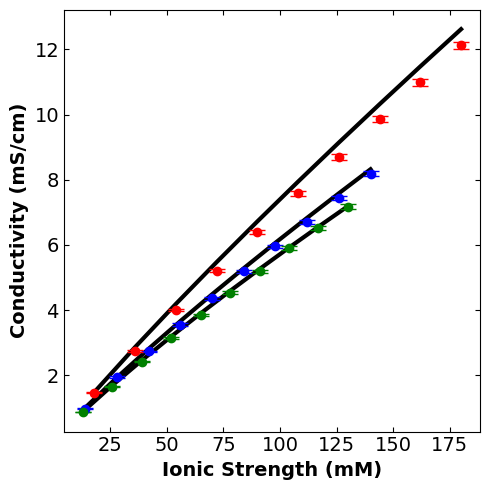

In [26]:
# bulk conductivity
specific_cond_21 = [specific_cond_nacl_21[i] + specific_cond_lacl3_11[i] for i in range(ndata4)]
specific_cond_22 = [specific_cond_nacl_22[i] + specific_cond_lacl3_12[i] for i in range(ndata4)]
specific_cond_23 = [specific_cond_nacl_23[i] + specific_cond_lacl3_13[i] for i in range(ndata4)]

# plot comparison of the Shedlovsky model predictions with the data
fig = plt.figure(figsize=(5, 5))
plt.plot(ionic_strength_na_la_1_1, specific_cond_21, "-", color="black", linewidth=3, 
         label="Shedlovsky")
plt.plot(ionic_strength_na_la_1_2, specific_cond_23, "-", color="black", linewidth=3)
plt.plot(ionic_strength_na_la_3_1, specific_cond_22, "-", linewidth=3, color="black")
plt.errorbar(
    ionic_strength_na_la_1_1, cond_exp3, yerr=error_na_la_1_1, fmt='o', ecolor='blue', capsize=6, 
    markersize=6, markerfacecolor='blue', markeredgecolor='blue', label='1:1 Cation Data')
plt.errorbar(
    ionic_strength_na_la_1_2, cond_exp33, yerr=error_na_la_1_2, fmt='o', ecolor='green', capsize=6, 
    markersize=6, markerfacecolor='green', markeredgecolor='green', label='1:2 Cation Data')
plt.errorbar(
    ionic_strength_na_la_3_1, cond_exp32, yerr=error_na_la_3_1, fmt='o', ecolor='red', capsize=6, 
    markersize=6, markerfacecolor='red', markeredgecolor='red', label='3:1 Cation Data')
plt.xlabel("Ionic Strength (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Conductivity (mS/cm)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
# plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Binary_salts\shed_na_la.png")
plt.show()

In [27]:
# prediction residuals for NaCl and LaCl3
e3_2 = [specific_cond_21[i] - cond_exp3[i] for i in range(ndata4)]
e32_2 = [specific_cond_22[i] - cond_exp32[i] for i in range(ndata4)]
e33_2 = [specific_cond_23[i] - cond_exp33[i] for i in range(ndata4)]

The mean absolute percent error of 1:1 is: 2.1485932693189964
The mean absolute percent error of 3:1 is: 4.283803273173414
The mean absolute percent error of 1:2 is: 1.2957386675594806

The mean absolute error of 1:1 is: 0.0955349548632177
The mean absolute error of 3:1 is: 0.31360655525510905
The mean absolute error of 1:2 is: 0.03924223025017246

The mean squared error of 1:1 is: 0.01078532850090706
The mean squared error of 3:1 is: 0.12322525835687947
The mean squared error of 1:2 is: 0.001844898153499286


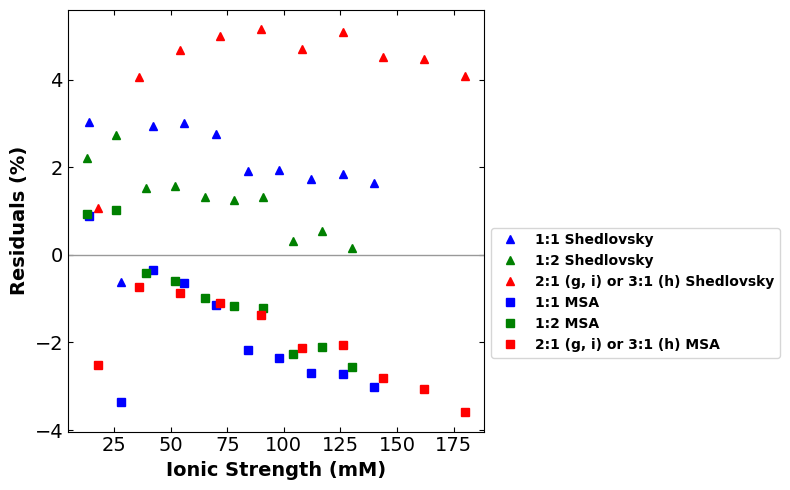

In [28]:
# percent prediction residuals
residuals_percent3_2 = [100*e3_2[i]/cond_exp3[i] for i in range(ndata4)]
residuals_percent32_2 = [100*e32_2[i]/cond_exp32[i] for i in range(ndata4)]
residuals_percent33_2 = [100*e33_2[i]/cond_exp33[i] for i in range(ndata4)]

# calculate the mean absolute percent error
residuals_percent3_2_abs = [np.abs(residuals_percent3_2[i]) for i in range(ndata4)]
residuals_percent32_2_abs = [np.abs(residuals_percent32_2[i]) for i in range(ndata4)]
residuals_percent33_2_abs = [np.abs(residuals_percent33_2[i]) for i in range(ndata4)]
print("The mean absolute percent error of 1:1 is:",np.mean(residuals_percent3_2_abs))
print("The mean absolute percent error of 3:1 is:",np.mean(residuals_percent32_2_abs))
print("The mean absolute percent error of 1:2 is:",np.mean(residuals_percent33_2_abs))

# calculate the mean absolute error
residuals_3_abs_shed = [np.abs(e3_2[i]) for i in range(ndata4)]
residuals_32_abs_shed = [np.abs(e32_2[i]) for i in range(ndata4)]
residuals_33_abs_shed = [np.abs(e33_2[i]) for i in range(ndata4)]
print("\nThe mean absolute error of 1:1 is:",np.mean(residuals_3_abs_shed))
print("The mean absolute error of 3:1 is:",np.mean(residuals_32_abs_shed))
print("The mean absolute error of 1:2 is:",np.mean(residuals_33_abs_shed))

# calculate the mean squared error
sq_residuals_3_shed = [e3_2[i]**2 for i in range(ndata4)]
sq_residuals_32_shed = [e32_2[i]**2 for i in range(ndata4)]
sq_residuals_33_shed = [e33_2[i]**2 for i in range(ndata4)]
print("\nThe mean squared error of 1:1 is:",np.mean(sq_residuals_3_shed))
print("The mean squared error of 3:1 is:",np.mean(sq_residuals_32_shed))
print("The mean squared error of 1:2 is:",np.mean(sq_residuals_33_shed))

# plot the prediction residuals of the Shedlovsky and MSA models
fig = plt.figure(figsize=(8, 5))
plt.axhline(0, color="0.6", lw=1)
plt.plot(ionic_strength_na_la_1_1, residuals_percent3_2, "^", color="blue", 
         label="1:1 Shedlovsky")
plt.plot(ionic_strength_na_la_1_2, residuals_percent33_2, "^", color="green", 
         label="1:2 Shedlovsky")
plt.plot(ionic_strength_na_la_3_1, residuals_percent32_2, "^", color="red", 
         label="2:1 (g, i) or 3:1 (h) Shedlovsky")
plt.plot(ionic_strength_na_la_1_1, residuals_percent3, "s", color="blue", 
         label="1:1 MSA")
plt.plot(ionic_strength_na_la_1_2, residuals_percent33, "s", color="green", 
         label="1:2 MSA")
plt.plot(ionic_strength_na_la_3_1, residuals_percent32, "s", color="red", 
         label="2:1 (g, i) or 3:1 (h) MSA")
plt.xlabel("Ionic Strength (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"}, bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig(r".\Binary_salts\msa_shed_na_la_residuals_per.png")
plt.show()

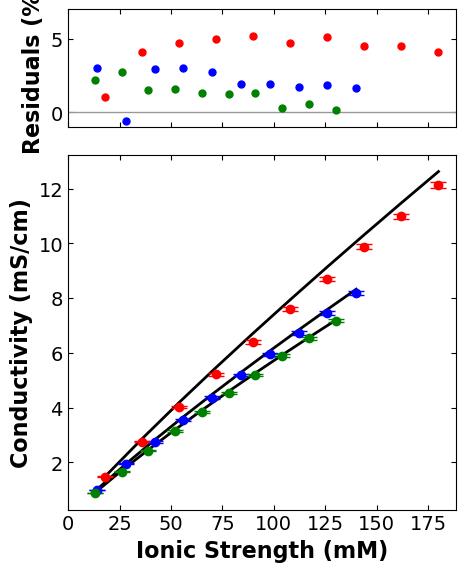

In [29]:
# generate paper figure for the Shedlovsky model
fig = plt.figure(figsize=(5, 6.5))
gs = GridSpec(2, 1, height_ratios=[1, 3], hspace=0.12)

ax_res = fig.add_subplot(gs[0])
ax_cond = fig.add_subplot(gs[1], sharex=ax_res)

# top plot
ax_res.axhline(0, color="0.6", lw=1)
ax_res.plot(ionic_strength_na_la_1_1, residuals_percent3_2, ".", color="blue", markersize=10,)
ax_res.plot(ionic_strength_na_la_1_2, residuals_percent33_2, ".", color="green", markersize=10,)
ax_res.plot(ionic_strength_na_la_3_1, residuals_percent32_2, ".", color="red", markersize=10,)
ax_res.set_ylabel("Residuals (%)", fontsize=16, fontweight="bold")
ax_res.set_ylim(-1, 7)

ax_res.tick_params(direction="in", top=True, right=True, labelsize=14)
plt.setp(ax_res.get_xticklabels(), visible=False)

# bottom plot
ax_cond.plot(ionic_strength_na_la_1_1, specific_cond_21, "-", color="black", linewidth=2,)
ax_cond.plot(ionic_strength_na_la_1_2, specific_cond_23, "-", color="black", linewidth=2)
ax_cond.plot(ionic_strength_na_la_3_1, specific_cond_22, "-", color="black", linewidth=2)
plt.errorbar(
    ionic_strength_na_la_1_1, cond_exp3, yerr=error_na_la_1_1, fmt='o', ecolor='blue', capsize=6, 
    markersize=6, markerfacecolor='blue', markeredgecolor='blue', label='1:1 Cation Data')
plt.errorbar(
    ionic_strength_na_la_1_2, cond_exp33, yerr=error_na_la_1_2, fmt='o', ecolor='green', capsize=6, 
    markersize=6, markerfacecolor='green', markeredgecolor='green', label='1:2 Cation Data')
plt.errorbar(
    ionic_strength_na_la_3_1, cond_exp32, yerr=error_na_la_3_1, fmt='o', ecolor='red', capsize=6, 
    markersize=6, markerfacecolor='red', markeredgecolor='red', label='3:1 Cation Data')

ax_cond.set_xlabel("Ionic Strength (mM)", fontsize=16, fontweight="bold")
ax_cond.set_ylabel("Conductivity (mS/cm)", fontsize=16, fontweight="bold")

ax_cond.set_xticks([0, 25, 50, 75, 100, 125, 150, 175])
ax_cond.tick_params(direction="in", top=True, right=True, labelsize=14)

plt.savefig(r".\Binary_salts\shed_na_la_combined.png")
plt.show()

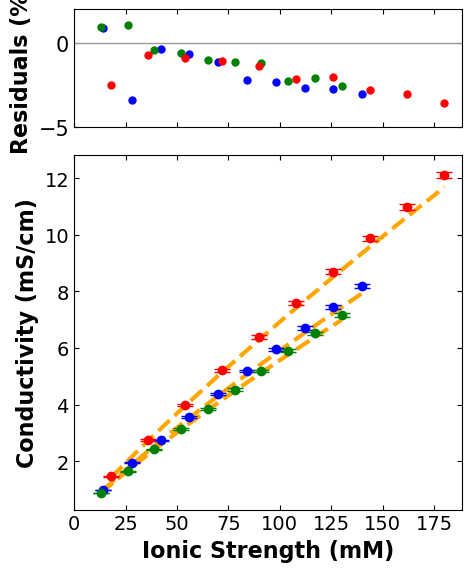

In [30]:
# generate paper figure for the MSA model
fig = plt.figure(figsize=(5, 6.5))
gs = GridSpec(2, 1, height_ratios=[1, 3], hspace=0.12)

ax_res = fig.add_subplot(gs[0])
ax_cond = fig.add_subplot(gs[1], sharex=ax_res)

# top plot
ax_res.axhline(0, color="0.6", lw=1)
ax_res.plot(ionic_strength_na_la_1_1, residuals_percent3, ".", color="blue", markersize=10,)
ax_res.plot(ionic_strength_na_la_1_2, residuals_percent33, ".", color="green", markersize=10,)
ax_res.plot(ionic_strength_na_la_3_1, residuals_percent32, ".", color="red", markersize=10,)

ax_res.set_ylabel("Residuals (%)", fontsize=16, fontweight="bold")
ax_res.set_ylim(-5, 2)
ax_res.tick_params(direction="in", top=True, right=True, labelsize=15)
plt.setp(ax_res.get_xticklabels(), visible=False)

# bottom plot
ax_cond.plot(ionic_strength_na_la_1_1, all_cond_calc_con3, "--", color="orange", linewidth=3,)
ax_cond.plot(ionic_strength_na_la_1_2, all_cond_calc_con33, "--", color="orange", linewidth=3)
ax_cond.plot(ionic_strength_na_la_3_1, all_cond_calc_con32, "--", color="orange", linewidth=3)
plt.errorbar(
    ionic_strength_na_la_1_1, cond_exp3, yerr=error_na_la_1_1, fmt='o', ecolor='blue', capsize=6, 
    markersize=6, markerfacecolor='blue', markeredgecolor='blue', label='1:1 Cation Data')
plt.errorbar(
    ionic_strength_na_la_1_2, cond_exp33, yerr=error_na_la_1_2, fmt='o', ecolor='green', capsize=6, 
    markersize=6, markerfacecolor='green', markeredgecolor='green', label='1:2 Cation Data')
plt.errorbar(
    ionic_strength_na_la_3_1, cond_exp32, yerr=error_na_la_3_1, fmt='o', ecolor='red', capsize=6, 
    markersize=6, markerfacecolor='red', markeredgecolor='red', label='3:1 Cation Data')

ax_cond.set_xlabel("Ionic Strength (mM)", fontsize=16, fontweight="bold")
ax_cond.set_ylabel("Conductivity (mS/cm)", fontsize=16, fontweight="bold")

ax_cond.set_xticks([0, 25, 50, 75, 100, 125, 150, 175])
ax_cond.tick_params(direction="in", top=True, right=True, labelsize=14)

plt.savefig(r".\Binary_salts\msa_na_la_combined.png")
plt.show()

## CaCl2 and LaCl3 Model Comparison

### CaCl2

In [31]:
# constants
a_CaCl2_LaCl3 = (a_CaCl2 + a_LaCl3)/2

# concentration in M
conc_cacl2_21 = [CaCl2_conc2[i]*10**(-3) for i in range(ndata2)]
conc_cacl2_22 = [CaCl2_conc22[i]*10**(-3) for i in range(ndata2)]
conc_cacl2_23 = [CaCl2_conc23[i]*10**(-3) for i in range(ndata2)]

# conductivity in milli.S/cm
specific_cond_cacl2_21 = cd.shedlovsky(conc_cacl2_21, T, epsilon, eta_shed, lambda_0_CaCl2, 
                                       a_CaCl2_LaCl3, z_Ca, z_Cl, lambda_0_Ca, lambda_0_Cl)
specific_cond_cacl2_22 = cd.shedlovsky(conc_cacl2_22, T, epsilon, eta_shed, lambda_0_CaCl2, 
                                       a_CaCl2_LaCl3, z_Ca, z_Cl, lambda_0_Ca, lambda_0_Cl)
specific_cond_cacl2_23 = cd.shedlovsky(conc_cacl2_23, T, epsilon, eta_shed, lambda_0_CaCl2, 
                                       a_CaCl2_LaCl3, z_Ca, z_Cl, lambda_0_Ca, lambda_0_Cl)

### LaCl3

In [32]:
# concentration in M
conc_lacl3_21 = [LaCl3_conc[i]*10**(-3) for i in range(ndata2)]
conc_lacl3_22 = [LaCl3_conc12[i]*10**(-3) for i in range(ndata2)]
conc_lacl3_23 = [LaCl3_conc13[i]*10**(-3) for i in range(ndata2)]

# conductivity in milli.S/cm
specific_cond_lacl3_21 = cd.shedlovsky(conc_lacl3_21, T, epsilon, eta_shed, lambda_0_LaCl3, 
                                       a_CaCl2_LaCl3, z_La, z_Cl, lambda_0_La, lambda_0_Cl)
specific_cond_lacl3_22 = cd.shedlovsky(conc_lacl3_22, T, epsilon, eta_shed, lambda_0_LaCl3, 
                                       a_CaCl2_LaCl3, z_La, z_Cl, lambda_0_La, lambda_0_Cl)
specific_cond_lacl3_23 = cd.shedlovsky(conc_lacl3_23, T, epsilon, eta_shed, lambda_0_LaCl3, 
                                       a_CaCl2_LaCl3, z_La, z_Cl, lambda_0_La, lambda_0_Cl)

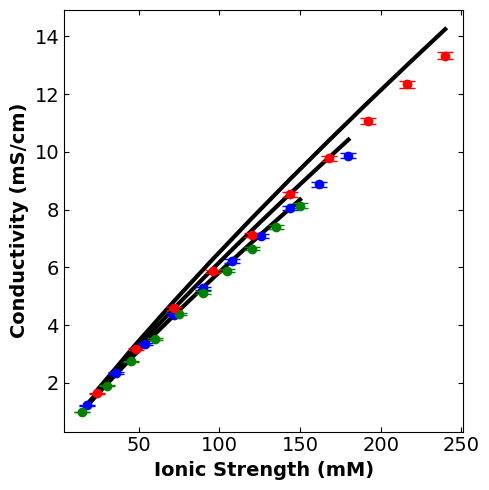

In [33]:
# bulk conductivity
specific_cond_31 = [specific_cond_cacl2_21[i] + specific_cond_lacl3_21[i] 
                    for i in range(ndata2)]
specific_cond_32 = [specific_cond_cacl2_22[i] + specific_cond_lacl3_22[i] 
                    for i in range(ndata2)]
specific_cond_33 = [specific_cond_cacl2_23[i] + specific_cond_lacl3_23[i] 
                    for i in range(ndata2)]

# plot comparison of the Shedlovsky model predictions with the data
fig = plt.figure(figsize=(5, 5))
plt.plot(ionic_strength_ca_la_1_1, specific_cond_31, "-", color="black", linewidth=3, 
         label="Shedlovsky")
plt.plot(ionic_strength_ca_la_1_2, specific_cond_33, "-", color="black", linewidth=3)
plt.plot(ionic_strength_ca_la_2_1, specific_cond_32, "-", linewidth=3, color="black")
plt.errorbar(
    ionic_strength_ca_la_1_1, cond_exp2, yerr=error_ca_la_1_1, fmt='o', ecolor='blue', capsize=6, 
    markersize=6, markerfacecolor='blue', markeredgecolor='blue', label='1:1 Cation Data')
plt.errorbar(
    ionic_strength_ca_la_1_2, cond_exp23, yerr=error_ca_la_1_2, fmt='o', ecolor='green', capsize=6, 
    markersize=6, markerfacecolor='green', markeredgecolor='green', label='1:2 Cation Data')
plt.errorbar(
    ionic_strength_ca_la_2_1, cond_exp22, yerr=error_ca_la_2_1, fmt='o', ecolor='red', capsize=6, 
    markersize=6, markerfacecolor='red', markeredgecolor='red', label='2:1 Cation Data')
plt.xlabel("Ionic Strength (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Conductivity (mS/cm)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
# plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Binary_salts\shed_ca_la.png")
plt.show()

In [34]:
# predictions residuals for CaCl2 and LaCl3
e2_2 = [specific_cond_31[i] - cond_exp2[i] for i in range(ndata2)]
e22_2 = [specific_cond_32[i] - cond_exp22[i] for i in range(ndata2)]
e23_2 = [specific_cond_33[i] - cond_exp23[i] for i in range(ndata2)]

The mean absolute percent error of 1:1 is: 5.593056137741167
The mean absolute percent error of 2:1 is: 6.243006136677245
The mean absolute percent error of 1:2 is: 3.2372085022507155

The mean absolute error of 1:1 is: 0.3472789882657546
The mean absolute error of 2:1 is: 0.4875436887962965
The mean absolute error of 1:2 is: 0.1506568525139777

The mean squared error of 1:1 is: 0.15986522681235935
The mean squared error of 2:1 is: 0.29589935879583645
The mean squared error of 1:2 is: 0.02736979780685391


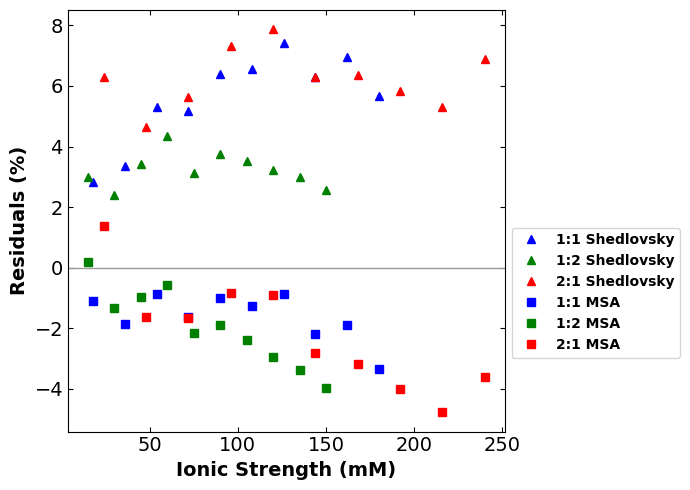

In [35]:
# percent prediction residuals
residuals_percent2_2 = [100*e2_2[i]/cond_exp2[i] for i in range(ndata2)]
residuals_percent22_2 = [100*e22_2[i]/cond_exp22[i] for i in range(ndata2)]
residuals_percent23_2 = [100*e23_2[i]/cond_exp23[i] for i in range(ndata2)]

# calculate the mean absolute percent error
residuals_percent2_2_abs = [np.abs(residuals_percent2_2[i]) for i in range(ndata2)]
residuals_percent22_2_abs = [np.abs(residuals_percent22_2[i]) for i in range(ndata2)]
residuals_percent23_2_abs = [np.abs(residuals_percent23_2[i]) for i in range(ndata2)]
print("The mean absolute percent error of 1:1 is:",np.mean(residuals_percent2_2_abs))
print("The mean absolute percent error of 2:1 is:",np.mean(residuals_percent22_2_abs))
print("The mean absolute percent error of 1:2 is:",np.mean(residuals_percent23_2_abs))

# calculate the mean absolute error
residuals_2_abs_shed = [np.abs(e2_2[i]) for i in range(ndata2)]
residuals_22_abs_shed = [np.abs(e22_2[i]) for i in range(ndata2)]
residuals_23_abs_shed = [np.abs(e23_2[i]) for i in range(ndata2)]
print("\nThe mean absolute error of 1:1 is:",np.mean(residuals_2_abs_shed))
print("The mean absolute error of 2:1 is:",np.mean(residuals_22_abs_shed))
print("The mean absolute error of 1:2 is:",np.mean(residuals_23_abs_shed))

# calculate the mean squared error
sq_residuals_2_shed = [e2_2[i]**2 for i in range(ndata2)]
sq_residuals_22_shed = [e22_2[i]**2 for i in range(ndata2)]
sq_residuals_23_shed = [e23_2[i]**2 for i in range(ndata2)]
print("\nThe mean squared error of 1:1 is:",np.mean(sq_residuals_2_shed))
print("The mean squared error of 2:1 is:",np.mean(sq_residuals_22_shed))
print("The mean squared error of 1:2 is:",np.mean(sq_residuals_23_shed))

# plot the prediction residuals of the Shedlovsky and MSA models
fig = plt.figure(figsize=(7, 5))
plt.axhline(0, color="0.6", lw=1)
plt.plot(ionic_strength_ca_la_1_1, residuals_percent2_2, "^", color="blue", 
         label="1:1 Shedlovsky")
plt.plot(ionic_strength_ca_la_1_2, residuals_percent23_2, "^", color="green", 
         label="1:2 Shedlovsky")
plt.plot(ionic_strength_ca_la_2_1, residuals_percent22_2, "^", color="red", 
         label="2:1 Shedlovsky")
plt.plot(ionic_strength_ca_la_1_1, residuals_percent2, "s", color="blue", 
         label="1:1 MSA")
plt.plot(ionic_strength_ca_la_1_2, residuals_percent23, "s", color="green", 
         label="1:2 MSA")
plt.plot(ionic_strength_ca_la_2_1, residuals_percent22, "s", color="red", 
         label="2:1 MSA")
plt.xlabel("Ionic Strength (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"}, bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig(r".\Binary_salts\msa_shed_ca_la_residuals_per.png")
plt.show()

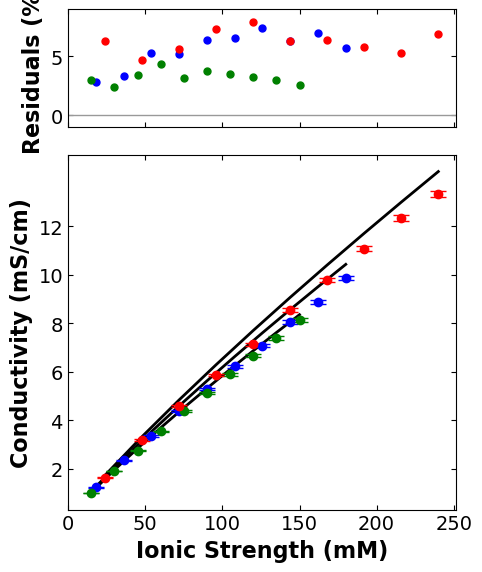

In [36]:
# generate paper figure for the Shedlovsky model
fig = plt.figure(figsize=(5, 6.5))
gs = GridSpec(2, 1, height_ratios=[1, 3], hspace=0.12)

ax_res = fig.add_subplot(gs[0])
ax_cond = fig.add_subplot(gs[1], sharex=ax_res)

# top plot
ax_res.axhline(0, color="0.6", lw=1)
ax_res.plot(ionic_strength_ca_la_1_1, residuals_percent2_2, ".", color="blue", markersize=10,)
ax_res.plot(ionic_strength_ca_la_1_2, residuals_percent23_2, ".", color="green", markersize=10,)
ax_res.plot(ionic_strength_ca_la_2_1, residuals_percent22_2, ".", color="red", markersize=10,)

ax_res.set_ylabel("Residuals (%)", fontsize=16, fontweight="bold")
ax_res.set_ylim(-1, 9)

ax_res.tick_params(direction="in", top=True, right=True, labelsize=14)
plt.setp(ax_res.get_xticklabels(), visible=False)

# bottom plot
ax_cond.plot(ionic_strength_ca_la_1_1, specific_cond_31, "-", color="black", linewidth=2,)
ax_cond.plot(ionic_strength_ca_la_1_2, specific_cond_33, "-", color="black", linewidth=2,)
ax_cond.plot(ionic_strength_ca_la_2_1, specific_cond_32, "-", color="black", linewidth=2,)
plt.errorbar(
    ionic_strength_ca_la_1_1, cond_exp2, yerr=error_ca_la_1_1, fmt='o', ecolor='blue', capsize=6, 
    markersize=6, markerfacecolor='blue', markeredgecolor='blue', label='1:1 Cation Data')
plt.errorbar(
    ionic_strength_ca_la_1_2, cond_exp23, yerr=error_ca_la_1_2, fmt='o', ecolor='green', capsize=6, 
    markersize=6, markerfacecolor='green', markeredgecolor='green', label='1:2 Cation Data')
plt.errorbar(
    ionic_strength_ca_la_2_1, cond_exp22, yerr=error_ca_la_2_1, fmt='o', ecolor='red', capsize=6, 
    markersize=6, markerfacecolor='red', markeredgecolor='red', label='2:1 Cation Data')

ax_cond.set_xlabel("Ionic Strength (mM)", fontsize=16, fontweight="bold")
ax_cond.set_ylabel("Conductivity (mS/cm)", fontsize=16, fontweight="bold")

ax_cond.set_xticks([0, 50, 100, 150, 200, 250])
ax_cond.set_yticks([2, 4, 6, 8, 10, 12])
ax_cond.tick_params(direction="in", top=True, right=True, labelsize=14)

plt.savefig(r".\Binary_salts\shed_ca_la_combined.png")
plt.show()

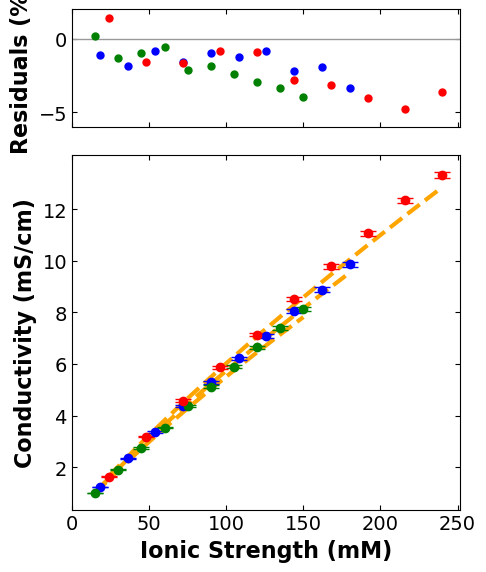

In [37]:
# generate paper figure for the MSA model
fig = plt.figure(figsize=(5, 6.5))
gs = GridSpec(2, 1, height_ratios=[1, 3], hspace=0.12)

ax_res = fig.add_subplot(gs[0])
ax_cond = fig.add_subplot(gs[1], sharex=ax_res)

# top plot
ax_res.axhline(0, color="0.6", lw=1)
ax_res.plot(ionic_strength_ca_la_1_1, residuals_percent2, ".", color="blue", markersize=10,)
ax_res.plot(ionic_strength_ca_la_1_2, residuals_percent23, ".", color="green", markersize=10,)
ax_res.plot(ionic_strength_ca_la_2_1, residuals_percent22, ".", color="red", markersize=10,)

ax_res.set_ylabel("Residuals (%)", fontsize=16, fontweight="bold")
ax_res.set_ylim(-6, 2)

ax_res.tick_params(direction="in", top=True, right=True, labelsize=14)
plt.setp(ax_res.get_xticklabels(), visible=False)

# bottom plot
ax_cond.plot(ionic_strength_ca_la_1_1, all_cond_calc_con2, "--", color="orange", linewidth=3,)
ax_cond.plot(ionic_strength_ca_la_1_2, all_cond_calc_con23, "--", color="orange", linewidth=3,)
ax_cond.plot(ionic_strength_ca_la_2_1, all_cond_calc_con22, "--", color="orange", linewidth=3,)
plt.errorbar(
    ionic_strength_ca_la_1_1, cond_exp2, yerr=error_ca_la_1_1, fmt='o', ecolor='blue', capsize=6, 
    markersize=6, markerfacecolor='blue', markeredgecolor='blue', label='1:1 Cation Data')
plt.errorbar(
    ionic_strength_ca_la_1_2, cond_exp23, yerr=error_ca_la_1_2, fmt='o', ecolor='green', capsize=6, 
    markersize=6, markerfacecolor='green', markeredgecolor='green', label='1:2 Cation Data')
plt.errorbar(
    ionic_strength_ca_la_2_1, cond_exp22, yerr=error_ca_la_2_1, fmt='o', ecolor='red', capsize=6, 
    markersize=6, markerfacecolor='red', markeredgecolor='red', label='2:1 Cation Data')

ax_cond.set_xlabel("Ionic Strength (mM)", fontsize=16, fontweight="bold")
ax_cond.set_ylabel("Conductivity (mS/cm)", fontsize=16, fontweight="bold")

ax_cond.set_xticks([0, 50, 100, 150, 200, 250])
ax_cond.set_yticks([2, 4, 6, 8, 10, 12])
ax_cond.tick_params(direction="in", top=True, right=True, labelsize=14)

plt.savefig(r".\Binary_salts\msa_ca_la_combined.png")
plt.show()